# Challenge Motiva/CCR — Sprint I
## Análise Exploratória de Dados (EDA) e Pré-processamento
### SP-021 — Rodoanel Mário Covas Oeste | Levantamentos: 13/03/2026 e 20/03/2026

**Problema:** Classificação do nível de vegetação por trecho e área ao longo da rodovia SP-021, com objetivo de priorizar intervenções de roçada antes que a vegetação atinja nível crítico (Nível 3: h > 30 cm).

**Formulação Data Science:**
- **X (features):** KM do trecho, tipo de área, nível medido em T1 (13/03), diferença temporal entre medições
- **y (target):** nível em T2 (20/03) — classificação multiclasse (1, 2, 3) ou flag binário `critico` (nível == 3)
- **f:** modelo de classificação supervisionada (Random Forest, XGBoost, etc.)

In [1]:
import requests
import io

# ============================================================
# Os dados são baixados automaticamente do GitHub.
# Nenhum arquivo externo é necessário — só rodar o notebook.
# ============================================================

URL_13 = "https://raw.githubusercontent.com/Luisin07/Sprint-Data/main/RA-RET-RO%C3%87-LIMP-2026-03-13.xlsx"
URL_20 = "https://raw.githubusercontent.com/Luisin07/Sprint-Data/main/RA-RET-RO%C3%87-LIMP-2026-03-20.xlsx"

print("Baixando dados do GitHub...")
FILE_13 = io.BytesIO(requests.get(URL_13).content)
FILE_20 = io.BytesIO(requests.get(URL_20).content)
print("Dados carregados com sucesso.")
print(f"  Levantamento 13/03/2026: {FILE_13.getbuffer().nbytes:,} bytes")
print(f"  Levantamento 20/03/2026: {FILE_20.getbuffer().nbytes:,} bytes")


Baixando dados do GitHub...
Dados carregados com sucesso.
  Levantamento 13/03/2026: 120,808 bytes
  Levantamento 20/03/2026: 120,783 bytes


---
## 1. Importações e Configurações

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Estilo visual
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

CORES_NIVEL = {1: '#2ecc71', 2: '#f39c12', 3: '#e74c3c'}
LABEL_NIVEL = {1: 'Nível 1 (h < 10cm)', 2: 'Nível 2 (10–30cm)', 3: 'Nível 3 (h > 30cm)'}

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


---
## 2. Carregamento e Parsing dos Dados

In [3]:
def parse_motiva(filepath, date_label):
    """
    Faz o parsing do formato unifilar da Motiva/CCR:
    - Extrai item, área, proporções por nível e nível por KM
    - Retorna DataFrame no formato tidy (long format)
    """
    df_raw = pd.read_excel(filepath, sheet_name='ROÇADA', header=None, engine='openpyxl')

    # Cabeçalho de KMs está na linha 8, colunas 5 em diante
    header_row = df_raw.iloc[8]
    kms = []
    for val in header_row[5:]:
        try:
            kms.append(float(val))
        except:
            kms.append(None)

    # Mapeamento linha → área (linhas com dados de nível)
    areas = {
        9:  'CANT. DISPOSITIVO EXT.',
        10: 'CANT. MARGINAL EXTERNA',
        13: 'CANT. LATERAL EXTERNA',
        16: 'CANT. CENTRAL EXTERNA',
        17: 'CANT. CENTRAL INTERNA',
        20: 'CANT. LATERAL INTERNA',
        23: 'CANT. MARGINAL INTERNA',
        24: 'CANT. DISPOSITIVO INT.',
    }

    records = []
    for row_idx, area_name in areas.items():
        row = df_raw.iloc[row_idx]
        item = row[0]

        # Proporções globais do levantamento (colunas 2, 3, 4)
        try: p1 = float(row[2])
        except: p1 = np.nan
        try: p2 = float(row[3])
        except: p2 = np.nan
        try: p3 = float(row[4])
        except: p3 = np.nan

        # Nível por KM
        for i, km_val in enumerate(kms):
            if km_val is None:
                continue
            cell = row[5 + i]
            nivel = np.nan
            if str(cell) not in ['nan', 'X', 'x', 'None', '']:
                try:
                    nivel = int(float(cell))
                except:
                    pass

            records.append({
                'data': date_label,
                'item': item,
                'area': area_name,
                'km': km_val,
                'nivel': nivel,
                'prop_nivel1': p1,
                'prop_nivel2': p2,
                'prop_nivel3': p3,
            })

    return pd.DataFrame(records)

# Carregando os dois levantamentos
FILE_13.seek(0)
df13 = parse_motiva(FILE_13, '2026-03-13')
FILE_20.seek(0)
df20 = parse_motiva(FILE_20, '2026-03-20')

df_all = pd.concat([df13, df20], ignore_index=True)
df_all['data'] = pd.to_datetime(df_all['data'])

print(f'Total de registros: {len(df_all)}')
print(f'Registros com nível medido: {df_all["nivel"].notna().sum()}')
print(f'Registros sem leitura (X): {df_all["nivel"].isna().sum()}')
df_all.head(10)

Total de registros: 960
Registros com nível medido: 496
Registros sem leitura (X): 464


,data,item,area,km,nivel,prop_nivel1,prop_nivel2,prop_nivel3
0,2026-03-13,1.1,CANT. DISPOSITIVO EXT.,0.0,NaN,0.727273,0.0,0.272727
1,2026-03-13,1.1,CANT. DISPOSITIVO EXT.,500.0,NaN,0.727273,0.0,0.272727
2,2026-03-13,1.1,CANT. DISPOSITIVO EXT.,1000.0,NaN,0.727273,0.0,0.272727
3,2026-03-13,1.1,CANT. DISPOSITIVO EXT.,1500.0,NaN,0.727273,0.0,0.272727
4,2026-03-13,1.1,CANT. DISPOSITIVO EXT.,2000.0,NaN,0.727273,0.0,0.272727
5,2026-03-13,1.1,CANT. DISPOSITIVO EXT.,2500.0,NaN,0.727273,0.0,0.272727
6,2026-03-13,1.1,CANT. DISPOSITIVO EXT.,3000.0,3.0,0.727273,0.0,0.272727
7,2026-03-13,1.1,CANT. DISPOSITIVO EXT.,3500.0,3.0,0.727273,0.0,0.272727
8,2026-03-13,1.1,CANT. DISPOSITIVO EXT.,4000.0,NaN,0.727273,0.0,0.272727
9,2026-03-13,1.1,CANT. DISPOSITIVO EXT.,4500.0,NaN,0.727273,0.0,0.272727


---
## 3. Análise Exploratória de Dados (EDA)

### 3.1 Visão Geral do Dataset

In [4]:
print('=== INFORMAÇÕES GERAIS ===')
print(f'Shape: {df_all.shape}')
print(f'Datas: {sorted(df_all["data"].dt.strftime("%d/%m/%Y").unique())}')
print(f'Áreas monitoradas: {df_all["area"].nunique()}')
print(f'KMs monitorados: {df_all["km"].nunique()} trechos (KM 0 ao KM 29+300)')
print()

print('=== DISTRIBUIÇÃO DE NÍVEIS (todos os registros com leitura) ===')
dist = df_all.dropna(subset=['nivel'])['nivel'].value_counts().sort_index()
for n, c in dist.items():
    pct = c / dist.sum() * 100
    print(f'  Nível {int(n)}: {c} trechos ({pct:.1f}%) — {LABEL_NIVEL[int(n)]}')

print()
print('=== TIPOS DE DADOS ===')
print(df_all.dtypes)

print()
print('=== NULOS ===')
print(df_all.isnull().sum())

=== INFORMAÇÕES GERAIS ===
Shape: (960, 8)
Datas: ['13/03/2026', '20/03/2026']
Áreas monitoradas: 8
KMs monitorados: 60 trechos (KM 0 ao KM 29+300)

=== DISTRIBUIÇÃO DE NÍVEIS (todos os registros com leitura) ===
  Nível 1: 342 trechos (69.0%) — Nível 1 (h < 10cm)
  Nível 2: 105 trechos (21.2%) — Nível 2 (10–30cm)
  Nível 3: 49 trechos (9.9%) — Nível 3 (h > 30cm)

=== TIPOS DE DADOS ===
data           datetime64[ns]
item                   object
area                   object
km                    float64
nivel                 float64
prop_nivel1           float64
prop_nivel2           float64
prop_nivel3           float64
dtype: object

=== NULOS ===
data             0
item             0
area             0
km               0
nivel          464
prop_nivel1      0
prop_nivel2      0
prop_nivel3      0
dtype: int64


### 3.2 Distribuição de Níveis por Data

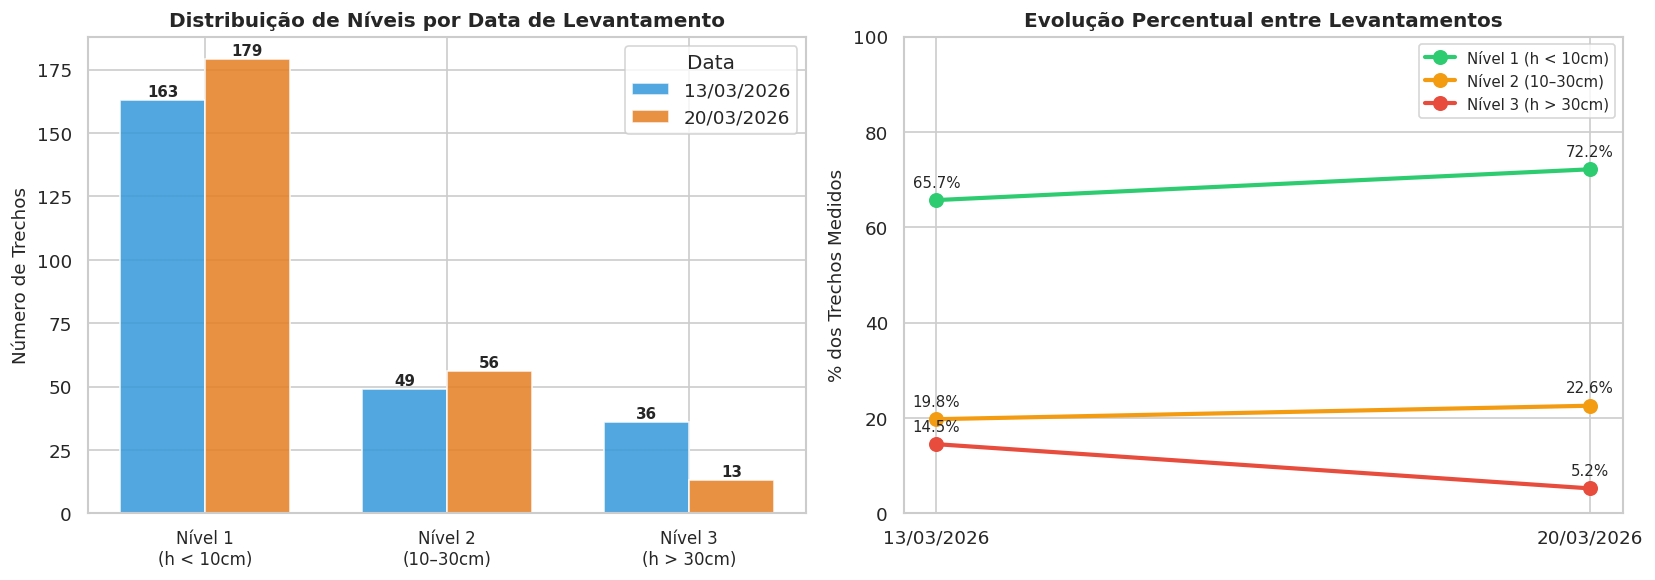

Figura 1 salva.


In [5]:
df_valid = df_all.dropna(subset=['nivel']).copy()
df_valid['nivel'] = df_valid['nivel'].astype(int)
df_valid['data_str'] = df_valid['data'].dt.strftime('%d/%m/%Y')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Contagem por nível e data ---
ax1 = axes[0]
contagem = df_valid.groupby(['data_str', 'nivel']).size().reset_index(name='count')
datas = sorted(contagem['data_str'].unique())
niveis = [1, 2, 3]
x = np.arange(len(niveis))
width = 0.35

for i, d in enumerate(datas):
    vals = [contagem[(contagem['data_str']==d) & (contagem['nivel']==n)]['count'].values[0]
            if len(contagem[(contagem['data_str']==d) & (contagem['nivel']==n)]) > 0 else 0
            for n in niveis]
    bars = ax1.bar(x + i*width, vals, width, label=d,
                   color=['#3498db','#e67e22'][i], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(v),
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xticks(x + width/2)
ax1.set_xticklabels(['Nível 1\n(h < 10cm)', 'Nível 2\n(10–30cm)', 'Nível 3\n(h > 30cm)'], fontsize=10)
ax1.set_ylabel('Número de Trechos', fontsize=11)
ax1.set_title('Distribuição de Níveis por Data de Levantamento', fontsize=12, fontweight='bold')
ax1.legend(title='Data')

# --- Gráfico 2: Evolução percentual ---
ax2 = axes[1]
pct_data = []
for d in datas:
    sub = df_valid[df_valid['data_str']==d]
    total = len(sub)
    for n in niveis:
        pct_data.append({'data': d, 'nivel': n, 'pct': len(sub[sub['nivel']==n])/total*100})

pct_df = pd.DataFrame(pct_data)
for n in niveis:
    sub = pct_df[pct_df['nivel']==n]
    ax2.plot(sub['data'], sub['pct'], marker='o', linewidth=2.5,
             color=CORES_NIVEL[n], label=LABEL_NIVEL[n], markersize=8)
    for _, row in sub.iterrows():
        ax2.annotate(f"{row['pct']:.1f}%", (row['data'], row['pct']),
                     textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

ax2.set_ylabel('% dos Trechos Medidos', fontsize=11)
ax2.set_title('Evolução Percentual entre Levantamentos', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('fig1_distribuicao_niveis.png', bbox_inches='tight')
plt.show()
print('Figura 1 salva.')

### 3.3 Análise por Área

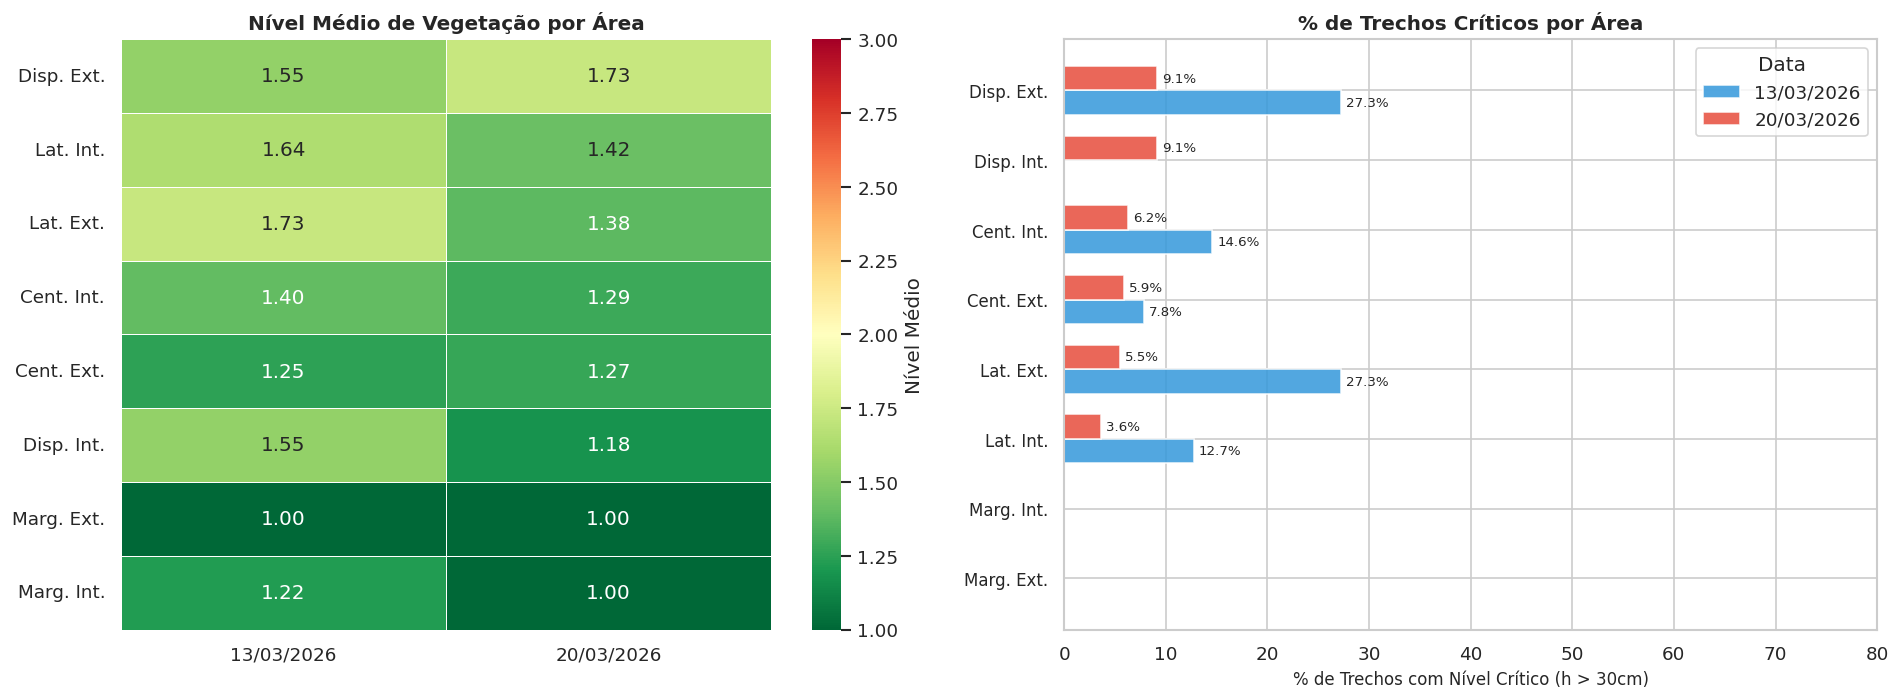

Figura 2 salva.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: Heatmap de nível médio por área e data ---
ax1 = axes[0]
pivot = df_valid.groupby(['area', 'data_str'])['nivel'].mean().unstack()
pivot = pivot.sort_values(pivot.columns[-1], ascending=False)

# Nomes curtos para o heatmap
short_names = {
    'CANT. DISPOSITIVO EXT.': 'Disp. Ext.',
    'CANT. MARGINAL EXTERNA': 'Marg. Ext.',
    'CANT. LATERAL EXTERNA':  'Lat. Ext.',
    'CANT. CENTRAL EXTERNA':  'Cent. Ext.',
    'CANT. CENTRAL INTERNA':  'Cent. Int.',
    'CANT. LATERAL INTERNA':  'Lat. Int.',
    'CANT. MARGINAL INTERNA': 'Marg. Int.',
    'CANT. DISPOSITIVO INT.': 'Disp. Int.',
}
pivot.index = [short_names.get(x, x) for x in pivot.index]

sns.heatmap(pivot, ax=ax1, annot=True, fmt='.2f', cmap='RdYlGn_r',
            vmin=1, vmax=3, linewidths=0.5, cbar_kws={'label': 'Nível Médio'})
ax1.set_title('Nível Médio de Vegetação por Área', fontsize=12, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('')

# --- Gráfico 2: Proporção de nível 3 (crítico) por área ---
ax2 = axes[1]
critico_por_area = df_valid.groupby(['area', 'data_str']).apply(
    lambda x: (x['nivel']==3).sum() / len(x) * 100
).reset_index(name='pct_critico')
critico_por_area['area_curta'] = critico_por_area['area'].map(short_names)

# Ordenar por valor no último levantamento
ordem = critico_por_area[critico_por_area['data_str']==sorted(critico_por_area['data_str'].unique())[-1]]\
        .sort_values('pct_critico', ascending=True)['area_curta'].tolist()

datas_sorted = sorted(critico_por_area['data_str'].unique())
colors_bar = ['#3498db', '#e74c3c']

y = np.arange(len(ordem))
h = 0.35
for i, d in enumerate(datas_sorted):
    sub = critico_por_area[critico_por_area['data_str']==d].set_index('area_curta')
    vals = [sub.loc[a, 'pct_critico'] if a in sub.index else 0 for a in ordem]
    bars = ax2.barh(y + i*h, vals, h, label=d, color=colors_bar[i], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        if v > 0:
            ax2.text(v + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{v:.1f}%', va='center', fontsize=8)

ax2.set_yticks(y + h/2)
ax2.set_yticklabels(ordem, fontsize=10)
ax2.set_xlabel('% de Trechos com Nível Crítico (h > 30cm)', fontsize=10)
ax2.set_title('% de Trechos Críticos por Área', fontsize=12, fontweight='bold')
ax2.legend(title='Data')
ax2.set_xlim(0, 80)

plt.tight_layout()
plt.savefig('fig2_analise_por_area.png', bbox_inches='tight')
plt.show()
print('Figura 2 salva.')

### 3.4 Mapa de Nível ao Longo da Rodovia (por KM)

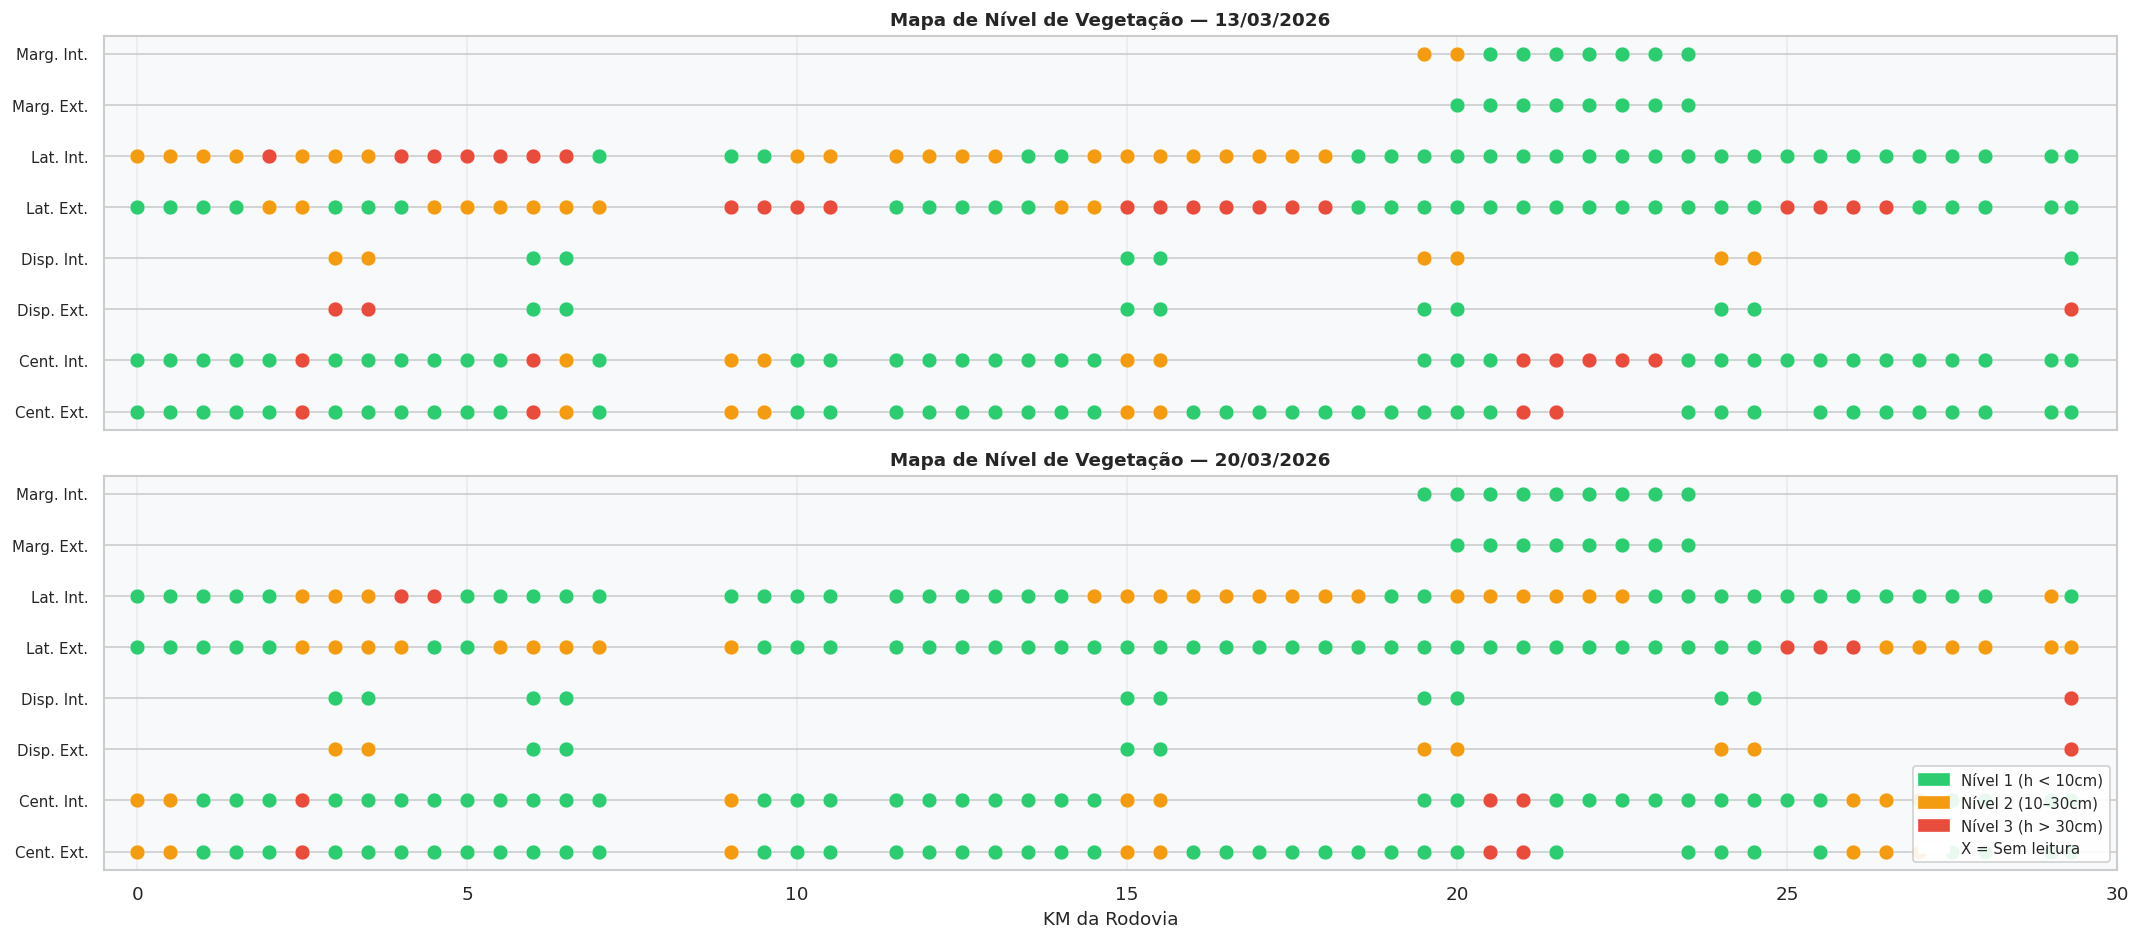

Figura 3 salva.


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

datas_plot = sorted(df_valid['data_str'].unique())

for ax, data_str in zip(axes, datas_plot):
    sub = df_valid[df_valid['data_str'] == data_str]
    areas_lista = sorted(sub['area'].unique())
    area_to_y = {a: i for i, a in enumerate(areas_lista)}

    for _, row in sub.iterrows():
        cor = CORES_NIVEL.get(row['nivel'], '#cccccc')
        ax.scatter(row['km']/1000, area_to_y[row['area']],
                   c=cor, s=80, zorder=3, edgecolors='white', linewidths=0.3)

    ax.set_yticks(list(area_to_y.values()))
    ax.set_yticklabels([short_names.get(a, a) for a in areas_lista], fontsize=9)
    ax.set_title(f'Mapa de Nível de Vegetação — {data_str}', fontsize=11, fontweight='bold')
    ax.set_xlim(-0.5, 30)
    ax.grid(axis='x', alpha=0.3)
    ax.set_facecolor('#f8f9fa')

# Legenda
patches = [mpatches.Patch(color=CORES_NIVEL[n], label=LABEL_NIVEL[n]) for n in [1,2,3]]
patches.append(mpatches.Patch(color='white', label='X = Sem leitura'))
axes[1].legend(handles=patches, loc='lower right', fontsize=9, framealpha=0.9)
axes[1].set_xlabel('KM da Rodovia', fontsize=11)

plt.tight_layout()
plt.savefig('fig3_mapa_km.png', bbox_inches='tight')
plt.show()
print('Figura 3 salva.')

### 3.5 Análise de Mudança de Nível entre Levantamentos

In [8]:
# Pivotando para comparar T1 vs T2 no mesmo trecho
df_pivot = df_valid.pivot_table(
    index=['area', 'km'],
    columns='data_str',
    values='nivel'
).reset_index()

col_t1, col_t2 = sorted(df_valid['data_str'].unique())
df_pivot.columns.name = None
df_pivot = df_pivot.rename(columns={col_t1: 'nivel_t1', col_t2: 'nivel_t2'})
df_pivot = df_pivot.dropna(subset=['nivel_t1', 'nivel_t2'])
df_pivot['delta_nivel'] = df_pivot['nivel_t2'] - df_pivot['nivel_t1']
df_pivot['critico_t2'] = (df_pivot['nivel_t2'] == 3).astype(int)

print(f'Trechos com leitura nos dois levantamentos: {len(df_pivot)}')
print(f'\nDistribuição da variação de nível (Δ = T2 - T1):')
print(df_pivot['delta_nivel'].value_counts().sort_index())
print(f'\nTrechos que pioraram (Δ > 0): {(df_pivot["delta_nivel"] > 0).sum()}')
print(f'Trechos estáveis (Δ = 0): {(df_pivot["delta_nivel"] == 0).sum()}')
print(f'Trechos que melhoraram (Δ < 0): {(df_pivot["delta_nivel"] < 0).sum()}')
print(f'\nTrechos com nível 3 (crítico) em T2: {df_pivot["critico_t2"].sum()}')

# Matriz de transição
print('\n=== MATRIZ DE TRANSIÇÃO (T1 → T2) ===')
trans = pd.crosstab(df_pivot['nivel_t1'].astype(int),
                    df_pivot['nivel_t2'].astype(int),
                    rownames=['T1 (13/03)'], colnames=['T2 (20/03)'])
print(trans)
df_pivot.head()

Trechos com leitura nos dois levantamentos: 248

Distribuição da variação de nível (Δ = T2 - T1):
delta_nivel
-2.0     22
-1.0     31
 0.0    162
 1.0     30
 2.0      3
Name: count, dtype: int64

Trechos que pioraram (Δ > 0): 33
Trechos estáveis (Δ = 0): 162
Trechos que melhoraram (Δ < 0): 53

Trechos com nível 3 (crítico) em T2: 13

=== MATRIZ DE TRANSIÇÃO (T1 → T2) ===
T2 (20/03)    1   2   3
T1 (13/03)             
1           130  30   3
2            27  22   0
3            22   4  10


,area,km,nivel_t1,nivel_t2,delta_nivel,critico_t2
0,CANT. CENTRAL EXTERNA,0.0,1.0,2.0,1.0,0
1,CANT. CENTRAL EXTERNA,500.0,1.0,2.0,1.0,0
2,CANT. CENTRAL EXTERNA,1000.0,1.0,1.0,0.0,0
3,CANT. CENTRAL EXTERNA,1500.0,1.0,1.0,0.0,0
4,CANT. CENTRAL EXTERNA,2000.0,1.0,1.0,0.0,0


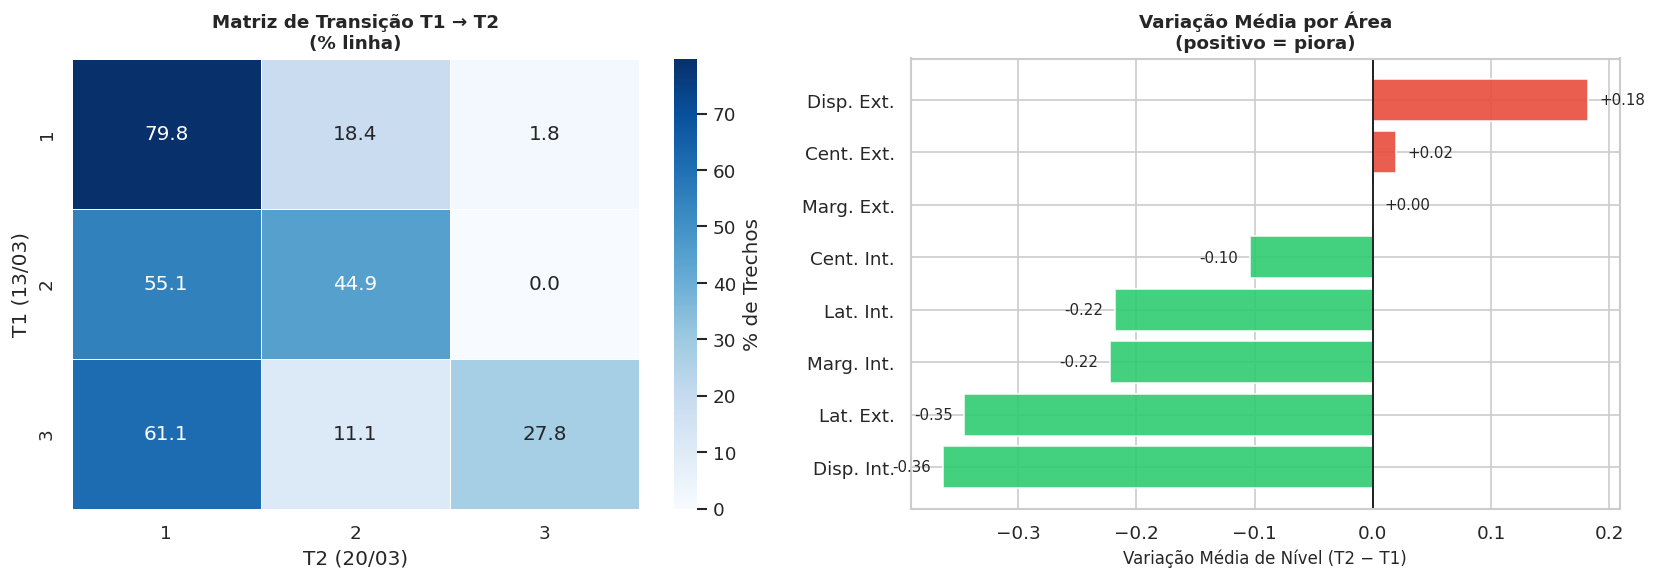

Figura 4 salva.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Matriz de transição ---
ax1 = axes[0]
trans_pct = trans.div(trans.sum(axis=1), axis=0) * 100
sns.heatmap(trans_pct, ax=ax1, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': '% de Trechos'})
ax1.set_title('Matriz de Transição T1 → T2\n(% linha)', fontsize=11, fontweight='bold')

# --- Distribuição de delta por área ---
ax2 = axes[1]
df_pivot['area_curta'] = df_pivot['area'].map(short_names)
delta_area = df_pivot.groupby('area_curta')['delta_nivel'].mean().sort_values()
colors_delta = ['#e74c3c' if v > 0 else '#2ecc71' if v < 0 else '#95a5a6' for v in delta_area]
bars = ax2.barh(delta_area.index, delta_area.values, color=colors_delta, edgecolor='white', alpha=0.9)
ax2.axvline(0, color='black', linewidth=1)
for bar, v in zip(bars, delta_area):
    ax2.text(v + (0.01 if v >= 0 else -0.01),
             bar.get_y() + bar.get_height()/2,
             f'{v:+.2f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)
ax2.set_xlabel('Variação Média de Nível (T2 − T1)', fontsize=10)
ax2.set_title('Variação Média por Área\n(positivo = piora)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_transicao_delta.png', bbox_inches='tight')
plt.show()
print('Figura 4 salva.')

### 3.6 Qualidade dos Dados

In [10]:
# Cobertura de leituras por área
cobertura = df_all.groupby(['area', 'data']).apply(
    lambda x: x['nivel'].notna().sum() / len(x) * 100
).reset_index(name='cobertura_pct')
cobertura['data_str'] = cobertura['data'].dt.strftime('%d/%m/%Y')
cobertura['area_curta'] = cobertura['area'].map(short_names)

print('=== COBERTURA DE LEITURAS POR ÁREA (%) ===')
pivot_cob = cobertura.pivot_table(index='area_curta', columns='data_str', values='cobertura_pct')
print(pivot_cob.round(1).to_string())

print('\n=== PROBLEMA IDENTIFICADO: DESBALANCEAMENTO DE CLASSES ===')
dist_pct = df_valid['nivel'].value_counts(normalize=True).sort_index() * 100
for n, p in dist_pct.items():
    flag = '⚠️ MINORIA — requer oversampling/SMOTE' if p < 15 else '✓'
    print(f'  Nível {int(n)}: {p:.1f}% {flag}')

print('\n=== CONSISTÊNCIA ENTRE LEVANTAMENTOS ===')
kms_t1 = set(df13.dropna(subset=['nivel'])[['area','km']].apply(tuple, axis=1))
kms_t2 = set(df20.dropna(subset=['nivel'])[['area','km']].apply(tuple, axis=1))
comuns = kms_t1 & kms_t2
print(f'  Trechos medidos em T1: {len(kms_t1)}')
print(f'  Trechos medidos em T2: {len(kms_t2)}')
print(f'  Trechos com leitura em AMBOS: {len(comuns)} (usados no modelo)')
print(f'  Apenas em T1: {len(kms_t1 - kms_t2)}')
print(f'  Apenas em T2: {len(kms_t2 - kms_t1)}')

=== COBERTURA DE LEITURAS POR ÁREA (%) ===
data_str    13/03/2026  20/03/2026
area_curta                        
Cent. Ext.        85.0        85.0
Cent. Int.        80.0        80.0
Disp. Ext.        18.3        18.3
Disp. Int.        18.3        18.3
Lat. Ext.         91.7        91.7
Lat. Int.         91.7        91.7
Marg. Ext.        13.3        13.3
Marg. Int.        15.0        15.0

=== PROBLEMA IDENTIFICADO: DESBALANCEAMENTO DE CLASSES ===
  Nível 1: 69.0% ✓
  Nível 2: 21.2% ✓
  Nível 3: 9.9% ⚠️ MINORIA — requer oversampling/SMOTE

=== CONSISTÊNCIA ENTRE LEVANTAMENTOS ===
  Trechos medidos em T1: 248
  Trechos medidos em T2: 248
  Trechos com leitura em AMBOS: 248 (usados no modelo)
  Apenas em T1: 0
  Apenas em T2: 0


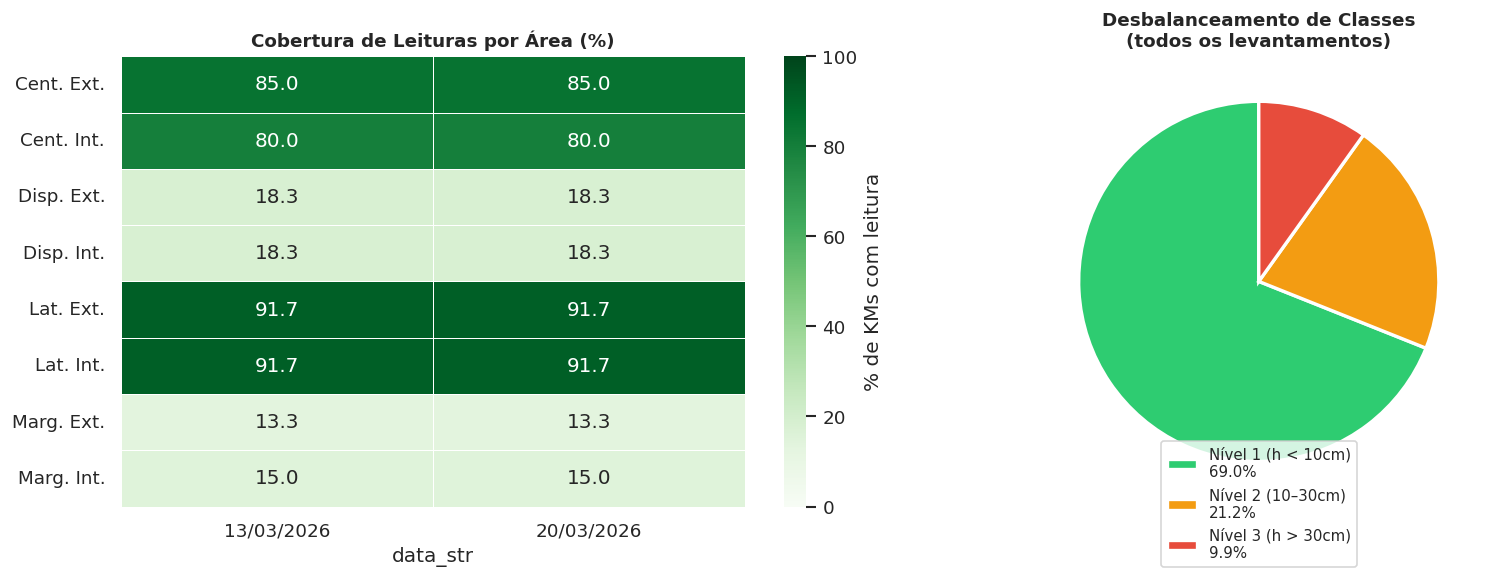

Figura 5 salva.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Heatmap de cobertura ---
ax1 = axes[0]
sns.heatmap(pivot_cob.round(1), ax=ax1, annot=True, fmt='.1f',
            cmap='Greens', vmin=0, vmax=100, linewidths=0.5,
            cbar_kws={'label': '% de KMs com leitura'})
ax1.set_title('Cobertura de Leituras por Área (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('')

# --- Pizza do desbalanceamento ---
ax2 = axes[1]
sizes = dist_pct.values
labels = [f'{LABEL_NIVEL[int(n)]}\n{p:.1f}%' for n, p in zip(dist_pct.index, sizes)]
colors = [CORES_NIVEL[int(n)] for n in dist_pct.index]
wedges, texts = ax2.pie(sizes, colors=colors, startangle=90,
                         wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.legend(wedges, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15), fontsize=9)
ax2.set_title('Desbalanceamento de Classes\n(todos os levantamentos)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig5_qualidade_dados.png', bbox_inches='tight')
plt.show()
print('Figura 5 salva.')

---
## 4. Pré-processamento

In [12]:
# === ETAPA 1: Construção do dataset de modelagem ===
# Cada linha = 1 trecho (área + KM) com features de T1 e target de T2

df_model = df_pivot[['area', 'km', 'nivel_t1', 'nivel_t2', 'delta_nivel', 'critico_t2']].copy()

# === ETAPA 2: Encoding da variável categórica 'area' ===
le = LabelEncoder()
df_model['area_enc'] = le.fit_transform(df_model['area'])
print('Encoding de áreas:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} → {cls}')

# === ETAPA 3: Normalização do KM (0 a 1) ===
df_model['km_norm'] = df_model['km'] / df_model['km'].max()

# === ETAPA 4: Features de posição relativa ===
# Tipo de área: interna (0) ou externa (1) — informação espacial importante
df_model['eh_externa'] = df_model['area'].str.contains('EXT').astype(int)

# === ETAPA 5: Intervalo entre medições (feature temporal) ===
DELTA_DIAS = (pd.to_datetime('2026-03-20') - pd.to_datetime('2026-03-13')).days
df_model['delta_dias'] = DELTA_DIAS  # constante nesse dataset; variável em uso contínuo

print(f'\nDataset de modelagem: {df_model.shape[0]} amostras, {df_model.shape[1]} colunas')
df_model.head(10)

Encoding de áreas:
  0 → CANT. CENTRAL EXTERNA
  1 → CANT. CENTRAL INTERNA
  2 → CANT. DISPOSITIVO EXT.
  3 → CANT. DISPOSITIVO INT.
  4 → CANT. LATERAL EXTERNA
  5 → CANT. LATERAL INTERNA
  6 → CANT. MARGINAL EXTERNA
  7 → CANT. MARGINAL INTERNA

Dataset de modelagem: 248 amostras, 10 colunas


,area,km,nivel_t1,nivel_t2,delta_nivel,critico_t2,area_enc,km_norm,eh_externa,delta_dias
0,CANT. CENTRAL EXTERNA,0.0,1.0,2.0,1.0,0,0,0.000000,1,7
1,CANT. CENTRAL EXTERNA,500.0,1.0,2.0,1.0,0,0,0.017065,1,7
2,CANT. CENTRAL EXTERNA,1000.0,1.0,1.0,0.0,0,0,0.034130,1,7
3,CANT. CENTRAL EXTERNA,1500.0,1.0,1.0,0.0,0,0,0.051195,1,7
4,CANT. CENTRAL EXTERNA,2000.0,1.0,1.0,0.0,0,0,0.068259,1,7
5,CANT. CENTRAL EXTERNA,2500.0,3.0,3.0,0.0,1,0,0.085324,1,7
6,CANT. CENTRAL EXTERNA,3000.0,1.0,1.0,0.0,0,0,0.102389,1,7
7,CANT. CENTRAL EXTERNA,3500.0,1.0,1.0,0.0,0,0,0.119454,1,7
8,CANT. CENTRAL EXTERNA,4000.0,1.0,1.0,0.0,0,0,0.136519,1,7
9,CANT. CENTRAL EXTERNA,4500.0,1.0,1.0,0.0,0,0,0.153584,1,7


In [13]:
# === ETAPA 6: Seleção de features e targets ===

FEATURES = ['area_enc', 'km_norm', 'nivel_t1', 'eh_externa', 'delta_dias']
TARGET_MULTI = 'nivel_t2'          # multiclasse: 1, 2, 3
TARGET_BIN   = 'critico_t2'        # binário: 0 ou 1 (crítico)

X = df_model[FEATURES]
y_multi = df_model[TARGET_MULTI].astype(int)
y_bin   = df_model[TARGET_BIN]

print('=== DATASET FINAL DE MODELAGEM ===')
print(f'Features (X): {FEATURES}')
print(f'Amostras: {len(X)}')
print(f'\nDistribuição do target multiclasse:')
print(y_multi.value_counts().sort_index())
print(f'\nDistribuição do target binário:')
print(y_bin.value_counts())

print('\n=== ESTATÍSTICAS DAS FEATURES ===')
print(X.describe().round(3))

=== DATASET FINAL DE MODELAGEM ===
Features (X): ['area_enc', 'km_norm', 'nivel_t1', 'eh_externa', 'delta_dias']
Amostras: 248

Distribuição do target multiclasse:
nivel_t2
1    179
2     56
3     13
Name: count, dtype: int64

Distribuição do target binário:
critico_t2
0    235
1     13
Name: count, dtype: int64

=== ESTATÍSTICAS DAS FEATURES ===
       area_enc  km_norm  nivel_t1  eh_externa  delta_dias
count   248.000  248.000   248.000     248.000       248.0
mean      2.859    0.519     1.488       0.504         7.0
std       2.156    0.297     0.736       0.501         0.0
min       0.000    0.000     1.000       0.000         7.0
25%       1.000    0.222     1.000       0.000         7.0
50%       4.000    0.538     1.000       1.000         7.0
75%       5.000    0.768     2.000       1.000         7.0
max       7.000    1.000     3.000       1.000         7.0


### 4.3 Balanceamento de Classes com SMOTE

=== ANTES DO SMOTE ===
Total de amostras: 248
critico_t2
Normal/Moderado    235
Crítico             13
Name: count, dtype: int64

=== APÓS O SMOTE ===
Total de amostras: 470
critico_t2
Normal/Moderado    235
Crítico            235
Name: count, dtype: int64


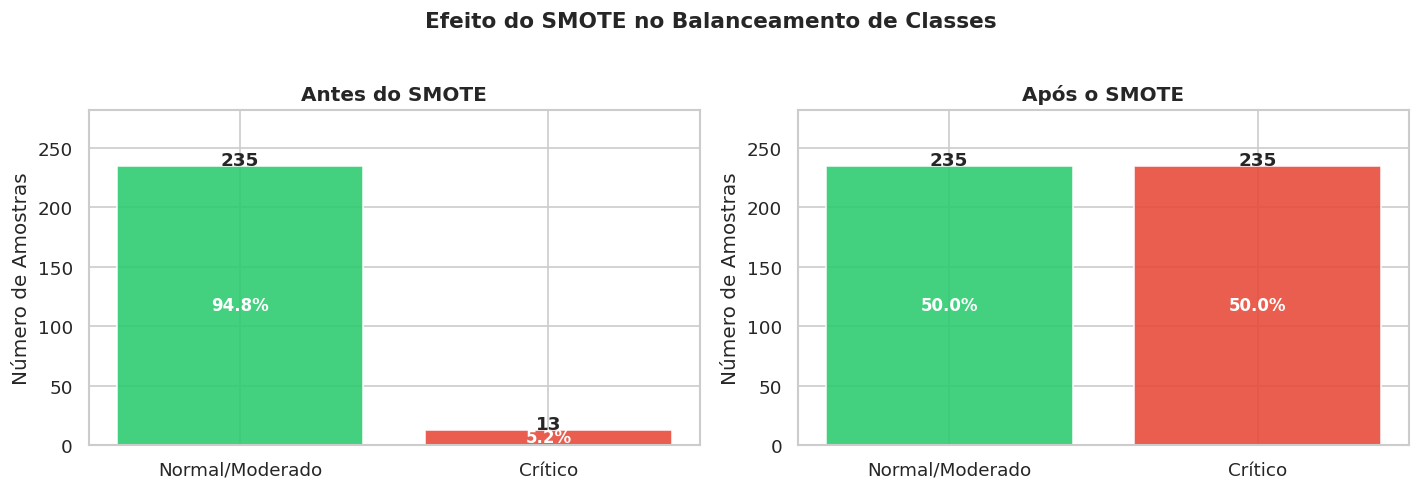


Dataset balanceado pronto para modelagem.


In [14]:
from imblearn.over_sampling import SMOTE

print('=== ANTES DO SMOTE ===')
print(f'Total de amostras: {len(X)}')
print(y_bin.value_counts().rename({0: 'Normal/Moderado', 1: 'Crítico'}))

# Aplicar SMOTE — gera amostras sintéticas da classe minoritária
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y_bin)

print(f'\n=== APÓS O SMOTE ===')
print(f'Total de amostras: {len(X_res)}')
import pandas as pd
print(pd.Series(y_res).value_counts().rename({0: 'Normal/Moderado', 1: 'Crítico'}))

# Visualização: antes vs depois
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cores = ['#2ecc71', '#e74c3c']
labels = ['Normal/Moderado', 'Crítico']

for ax, (y_plot, titulo) in zip(axes, [
    (y_bin, 'Antes do SMOTE'),
    (pd.Series(y_res), 'Após o SMOTE')
]):
    contagem = y_plot.value_counts().sort_index()
    bars = ax.bar(labels, contagem.values, color=cores, edgecolor='white', alpha=0.9)
    for bar, v in zip(bars, contagem.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(v), ha='center', fontweight='bold', fontsize=11)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylabel('Número de Amostras')
    ax.set_ylim(0, max(contagem.values) * 1.2)
    total = contagem.sum()
    for bar, v in zip(bars, contagem.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                f'{v/total*100:.1f}%', ha='center', va='center',
                color='white', fontweight='bold', fontsize=10)

plt.suptitle('Efeito do SMOTE no Balanceamento de Classes', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_smote.png', bbox_inches='tight')
plt.show()
print('\nDataset balanceado pronto para modelagem.')


---
## 5. Teste Inicial de Modelo (Random Forest)
> **Nota:** Conforme orientação do Challenge, modelos não são obrigatórios nesta Sprint. Este teste é exploratório para validar a viabilidade do pipeline.

In [15]:
# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.3, random_state=42, stratify=y_bin
)

# Modelo com class_weight para lidar com desbalanceamento
clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print('=== RELATÓRIO DE CLASSIFICAÇÃO — DETECÇÃO DE CRÍTICO (y binário) ===')
print(classification_report(y_test, y_pred, target_names=['Normal/Moderado', 'Crítico (N3)']))

# Importância de features
importances = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print('=== IMPORTÂNCIA DAS FEATURES ===')
print(importances.round(3))

=== RELATÓRIO DE CLASSIFICAÇÃO — DETECÇÃO DE CRÍTICO (y binário) ===
                 precision    recall  f1-score   support

Normal/Moderado       0.97      0.99      0.98        71
   Crítico (N3)       0.67      0.50      0.57         4

       accuracy                           0.96        75
      macro avg       0.82      0.74      0.78        75
   weighted avg       0.96      0.96      0.96        75

=== IMPORTÂNCIA DAS FEATURES ===
km_norm       0.516
nivel_t1      0.291
area_enc      0.161
eh_externa    0.033
delta_dias    0.000
dtype: float64


### 5.2 Random Forest com Dataset Balanceado (SMOTE)

=== RANDOM FOREST COM SMOTE ===
                 precision    recall  f1-score   support

Normal/Moderado       0.97      0.97      0.97        71
        Crítico       0.97      0.97      0.97        70

       accuracy                           0.97       141
      macro avg       0.97      0.97      0.97       141
   weighted avg       0.97      0.97      0.97       141



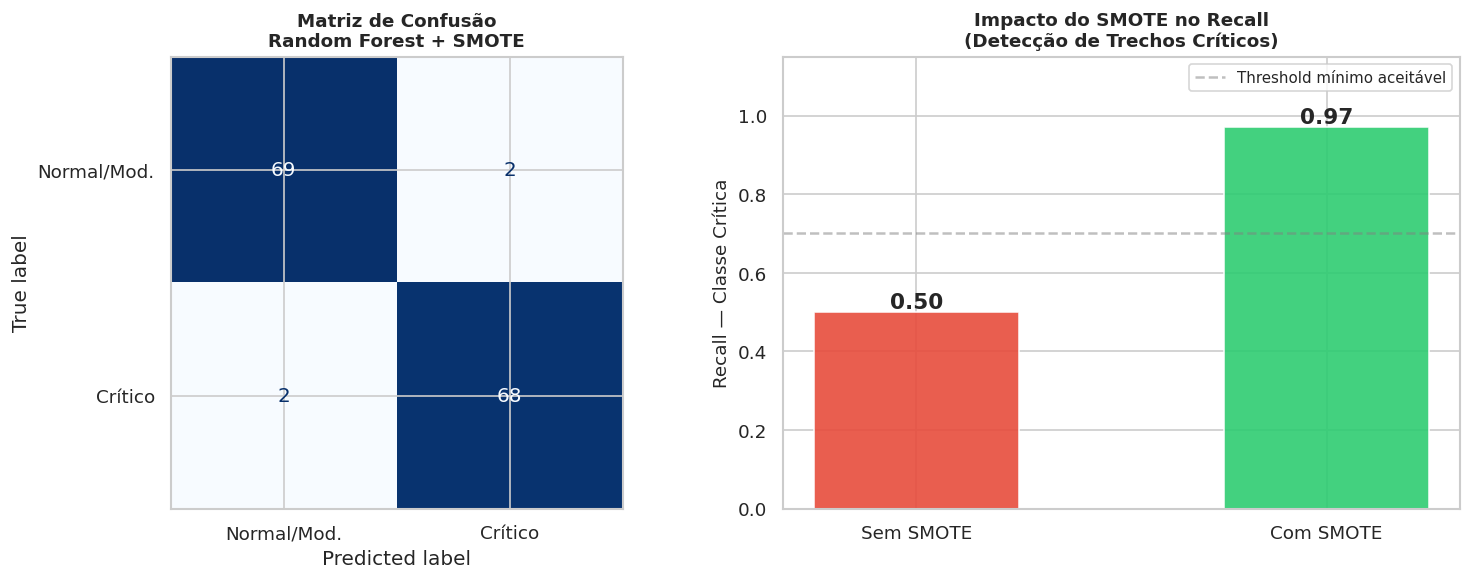

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Treino/teste com dados balanceados pelo SMOTE
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42, stratify=y_res
)

clf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
clf_smote.fit(X_train_s, y_train_s)
y_pred_s = clf_smote.predict(X_test_s)

print('=== RANDOM FOREST COM SMOTE ===')
print(classification_report(y_test_s, y_pred_s, target_names=['Normal/Moderado', 'Crítico']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusão
ax1 = axes[0]
cm = confusion_matrix(y_test_s, y_pred_s)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal/Mod.', 'Crítico'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Matriz de Confusão\nRandom Forest + SMOTE', fontsize=11, fontweight='bold')

# Comparação de recall: sem SMOTE vs com SMOTE
ax2 = axes[1]
from sklearn.metrics import recall_score
recall_sem = recall_score(y_test, clf.predict(X_test), pos_label=1)
recall_com = recall_score(y_test_s, y_pred_s, pos_label=1)

bars = ax2.bar(['Sem SMOTE', 'Com SMOTE'], [recall_sem, recall_com],
               color=['#e74c3c', '#2ecc71'], edgecolor='white', alpha=0.9, width=0.5)
for bar, v in zip(bars, [recall_sem, recall_com]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{v:.2f}', ha='center', fontweight='bold', fontsize=13)
ax2.set_ylabel('Recall — Classe Crítica', fontsize=11)
ax2.set_title('Impacto do SMOTE no Recall\n(Detecção de Trechos Críticos)', fontsize=11, fontweight='bold')
ax2.set_ylim(0, 1.15)
ax2.axhline(0.7, color='gray', linestyle='--', alpha=0.5, label='Threshold mínimo aceitável')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_smote_modelo.png', bbox_inches='tight')
plt.show()


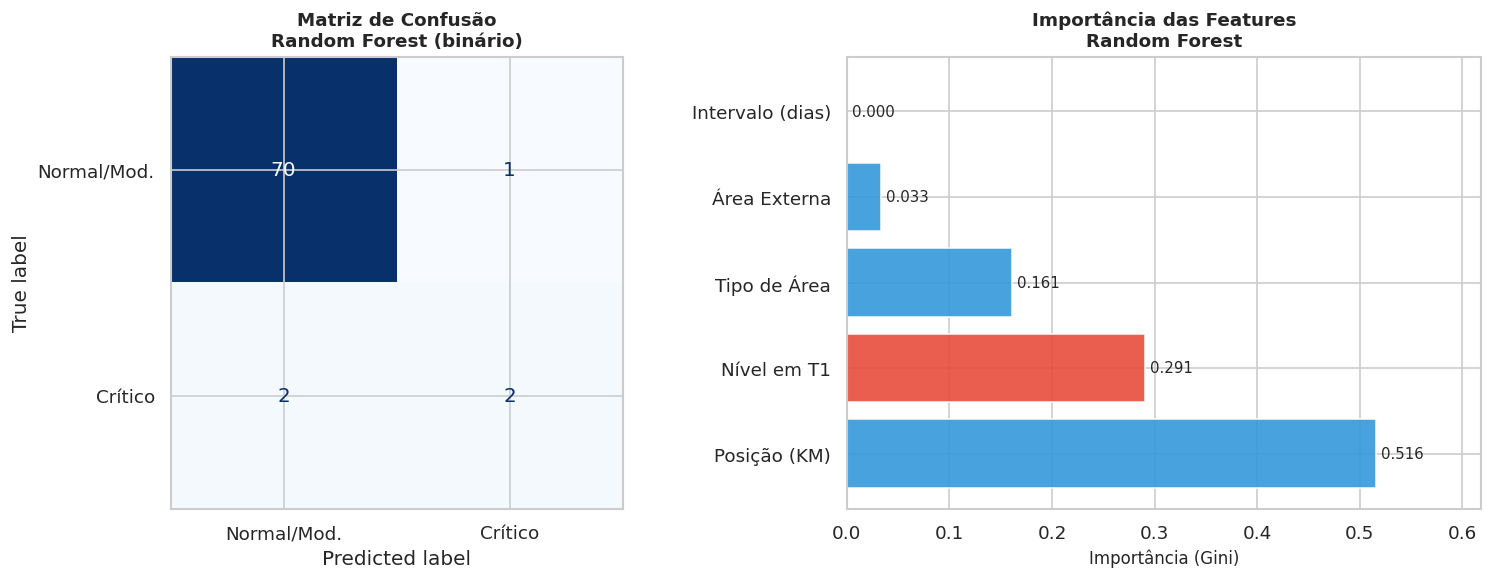

Figura 6 salva.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Matriz de confusão ---
ax1 = axes[0]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal/Mod.', 'Crítico'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Matriz de Confusão\nRandom Forest (binário)', fontsize=11, fontweight='bold')

# --- Importância de features ---
ax2 = axes[1]
feature_labels = {
    'area_enc': 'Tipo de Área',
    'km_norm': 'Posição (KM)',
    'nivel_t1': 'Nível em T1',
    'eh_externa': 'Área Externa',
    'delta_dias': 'Intervalo (dias)'
}
imp_plot = importances.rename(index=feature_labels)
colors_imp = ['#e74c3c' if imp_plot.index[i] == 'Nível em T1' else '#3498db'
              for i in range(len(imp_plot))]
bars = ax2.barh(imp_plot.index, imp_plot.values, color=colors_imp, edgecolor='white', alpha=0.9)
for bar, v in zip(bars, imp_plot.values):
    ax2.text(v + 0.005, bar.get_y() + bar.get_height()/2, f'{v:.3f}',
             va='center', fontsize=9)
ax2.set_xlabel('Importância (Gini)', fontsize=10)
ax2.set_title('Importância das Features\nRandom Forest', fontsize=11, fontweight='bold')
ax2.set_xlim(0, imp_plot.max() * 1.2)

plt.tight_layout()
plt.savefig('fig6_modelo_rf.png', bbox_inches='tight')
plt.show()
print('Figura 6 salva.')

---
## 6. Sumário Final e Próximos Passos

In [18]:
print('=' * 60)
print('SUMÁRIO — SPRINT I | CHALLENGE MOTIVA/CCR')
print('=' * 60)

print(f"""
DATASET
  Fonte       : Motiva/CCR — Rodoanel SP-021 Oeste
  Levantamentos: 13/03/2026 e 20/03/2026
  Trechos     : {len(df_model)} (área+KM com leitura nos dois períodos)
  Áreas       : 8 canteiros/faixas distintos
  KMs         : 0 ao 29+300 (intervalos de 500m)

FORMULAÇÃO DO PROBLEMA
  f(X) → y
  X    : [área, KM, nível_T1, tipo_externa, intervalo_dias]
  y    : nível_T2 (multiclasse 1/2/3) ou flag_crítico (binário)
  Tarefa: Classificação supervisionada

ACHADOS DA EDA
  - Nível 1 (normal)  : {(y_multi==1).sum()} trechos ({(y_multi==1).mean()*100:.1f}%)
  - Nível 2 (moderado): {(y_multi==2).sum()} trechos ({(y_multi==2).mean()*100:.1f}%)
  - Nível 3 (crítico) : {(y_multi==3).sum()} trechos ({(y_multi==3).mean()*100:.1f}%)
  - {(df_pivot['delta_nivel']>0).sum()} trechos pioraram entre T1 e T2
  - Áreas de maior risco: CANT. LATERAL INTERNA e CANT. DISPOSITIVO EXT.

QUALIDADE DOS DADOS
  - Desbalanceamento: Nível 3 é minoria → requer SMOTE ou class_weight
  - Cobertura: ~48% dos trechos têm leitura 'X' (sem dado) — padrão operacional
  - Consistência: estrutura idêntica entre os dois levantamentos

PRÓXIMOS PASSOS (Sprint II)
  1. Ampliar dataset com mais datas de levantamento
  2. Aplicar SMOTE para balancear classe crítica
  3. Testar XGBoost e comparar com Random Forest
  4. Incorporar features de sazonalidade/clima
  5. Avaliar compressão do modelo para Edge AI (TensorFlow Lite)
""")

# Salvar dataset final
df_model.to_csv('dataset_modelagem_motiva.csv', index=False)
print('Dataset de modelagem salvo: dataset_modelagem_motiva.csv')

SUMÁRIO — SPRINT I | CHALLENGE MOTIVA/CCR

DATASET
  Fonte       : Motiva/CCR — Rodoanel SP-021 Oeste
  Levantamentos: 13/03/2026 e 20/03/2026
  Trechos     : 248 (área+KM com leitura nos dois períodos)
  Áreas       : 8 canteiros/faixas distintos
  KMs         : 0 ao 29+300 (intervalos de 500m)

FORMULAÇÃO DO PROBLEMA
  f(X) → y
  X    : [área, KM, nível_T1, tipo_externa, intervalo_dias]
  y    : nível_T2 (multiclasse 1/2/3) ou flag_crítico (binário)
  Tarefa: Classificação supervisionada

ACHADOS DA EDA
  - Nível 1 (normal)  : 179 trechos (72.2%)
  - Nível 2 (moderado): 56 trechos (22.6%)
  - Nível 3 (crítico) : 13 trechos (5.2%)
  - 33 trechos pioraram entre T1 e T2
  - Áreas de maior risco: CANT. LATERAL INTERNA e CANT. DISPOSITIVO EXT.

QUALIDADE DOS DADOS
  - Desbalanceamento: Nível 3 é minoria → requer SMOTE ou class_weight
  - Cobertura: ~48% dos trechos têm leitura 'X' (sem dado) — padrão operacional
  - Consistência: estrutura idêntica entre os dois levantamentos

PRÓXIMOS PA